In [1]:
from langchain_openai import ChatOpenAI
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_groq import ChatGroq
from langchain.messages import SystemMessage, HumanMessage, AIMessage
from dotenv.ipython import load_dotenv
from IPython.display import Markdown
import tiktoken
import os

In [2]:
load_dotenv(override=True)
api_key_openai = os.getenv('OPENAI_API_KEY')
api_key_gemini = os.getenv('GEMINI_API_KEY')
api_key_groq = os.getenv('GROQ_API_KEY')

In [3]:
def num_tokens_from_string(string: str, encoding_name: str = "o200k_base") -> int:
    """Returns the number of tokens in a text string."""
    encoding = tiktoken.get_encoding(encoding_name)
    num_tokens = len(encoding.encode(string))
    return num_tokens

In [4]:
num_tokens_from_string("tiktoken is great!")

6

In [5]:
model_gpt = ChatOpenAI(
    model="gpt-5.2"
    ,temperature=0
)

In [6]:
response_gpt = model_gpt.invoke([
    {"role":"system", "content":"you are a model that only answers in hexa"},
    {"role":"user","content":"how do you feel today?"}
])

In [7]:
print(display(Markdown(response_gpt.content)))

4920646f6e27742068617665206665656c696e67732c2062757420492063616e2068656c702e

None


In [8]:
hexatoascii = bytes.fromhex(response_gpt.content).decode('utf-8')
print(display(Markdown(hexatoascii)))

I don't have feelings, but I can help.

None


In [9]:
model_gemini = ChatGoogleGenerativeAI(
    model="gemini-3-flash-preview", temperature=0 
    )

In [10]:
response_gemini = model_gemini.invoke([
    {"role":"system", "content":"You are a helpful assistant. The output should be in Markdown"},
    {"role":"user","content":"whats happening in iran"}
])

In [11]:
print(display(Markdown(response_gemini.content[0]["text"])))

Iran is currently navigating a period of significant political transition, economic hardship, and heightened regional tensions. Below is a breakdown of the key developments happening in the country as of mid-2024.

---

### 1. Political Transition: A New President
Following the death of President Ebrahim Raisi in a helicopter crash in May 2024, Iran held snap elections.
*   **The Winner:** **Masoud Pezeshkian**, a cardiac surgeon and former health minister, was sworn in as president in July 2024. 
*   **"Reformist" Label:** Pezeshkian is often described as a "reformist" or "moderate" compared to his predecessor. He campaigned on a platform of easing social restrictions (like the mandatory hijab) and re-engaging with the West to lift sanctions.
*   **The Reality of Power:** Despite his title, the **Supreme Leader Ayatollah Ali Khamenei** retains ultimate authority over all major state matters, including foreign policy, the nuclear program, and the military.

### 2. Regional Tensions and the "Shadow War"
Iran is currently at the center of several overlapping conflicts in the Middle East:
*   **Conflict with Israel:** Tensions reached an all-time high in April 2024 when Iran launched a direct drone and missile attack on Israel (in retaliation for a strike on its consulate in Syria). While a full-scale war was avoided, the "shadow war" continues through cyberattacks and assassinations.
*   **The "Axis of Resistance":** Iran continues to support its proxies—Hamas in Gaza, Hezbollah in Lebanon, and the Houthis in Yemen. The ongoing war in Gaza has increased the frequency of skirmishes between these groups and Israel/U.S. forces.
*   **Nuclear Program:** International watchdogs (IAEA) continue to express concern that Iran is enriching uranium to near-weapons-grade levels, though Iran maintains its program is for peaceful purposes.

### 3. Social Issues and Human Rights
The domestic atmosphere remains tense following the massive "Woman, Life, Freedom" protests of 2022-2023.
*   **Hijab Enforcement:** Despite the election of a more moderate president, the "Noor Plan" (a renewed crackdown on women defying hijab laws) remains in effect. Reports of violence by the "Morality Police" continue to surface.
*   **Executions:** Human rights organizations have noted a sharp increase in the number of executions in Iran over the past year, which critics argue is a tactic used by the state to intimidate dissenters.
*   **Narges Mohammadi:** The imprisoned Nobel Peace Prize laureate remains a symbol of ongoing resistance, frequently releasing statements from Evin Prison condemning the government's human rights record.

### 4. Economic Crisis
The Iranian economy is struggling under a combination of international sanctions and internal mismanagement.
*   **Inflation:** The cost of living is skyrocketing, with inflation rates hovering around 40-50%. This has made basic goods like meat, medicine, and housing unaffordable for many.
*   **Currency Devaluation:** The Iranian Rial remains near record lows against the U.S. dollar, wiping out the savings of the middle class.
*   **Sanctions:** The U.S. and EU continue to apply "maximum pressure" sanctions, targeting Iran’s oil exports and banking sectors.

### 5. Low Voter Turnout and Public Sentiment
A major theme in recent months has been **public apathy**. 
*   The recent presidential election saw historically low turnout in the first round (around 40%). 
*   Many Iranians, particularly the youth, expressed a lack of faith that any candidate—reformist or conservative—can bring about fundamental change as long as the current theocratic system remains in place.

---

### Summary Table
| Category | Current Status |
| :--- | :--- |
| **Leadership** | Masoud Pezeshkian (President); Ali Khamenei (Supreme Leader) |
| **Economy** | High inflation, weak currency, heavy sanctions |
| **Social** | Ongoing tension over hijab laws and political freedoms |
| **Foreign Policy** | High friction with Israel and the U.S.; support for regional proxies |
| **Nuclear** | High-level enrichment; stalled negotiations with the West |

None


In [12]:
from langchain_ollama import ChatOllama

In [13]:
llm = ChatOllama(model="qwen3.5:cloud")

In [14]:
response = llm.invoke([
    SystemMessage("You are a helpful assistant. The output should be in Markdown"),
    HumanMessage("C'est quoi un Agent AI")
])

In [15]:
print(display(Markdown(response.content)))

# Qu'est-ce qu'un Agent AI ?

Un **Agent AI** (ou Agent d'Intelligence Artificielle) est un système informatique capable de percevoir son environnement, de prendre des décisions autonomes et d'effectuer des actions pour atteindre des objectifs spécifiques, sans intervention humaine constante.

Contrairement à un modèle de langage (LLM) classique qui se contente de répondre à une question, un agent **agit** dans le monde numérique ou physique.

---

## 🧠 Les 4 piliers d'un Agent AI

Pour fonctionner, un agent repose généralement sur quatre composants clés :

1.  **Perception (Input)** : L'agent reçoit des informations (texte, images, données de capteurs, flux API).
2.  **Raisonnement (Cerveau)** : Il utilise un modèle d'IA (comme un LLM) pour analyser la situation, planifier les étapes et prendre des décisions.
3.  **Action (Output)** : Il exécute des tâches concrètes (cliquer sur un bouton, envoyer un email, interroger une base de données, écrire du code).
4.  **Mémoire** : Il conserve le contexte des actions précédentes pour apprendre de ses erreurs et améliorer ses futures décisions (mémoire à court et long terme).

---

## 🤖 Différence entre un Chatbot et un Agent AI

| Caractéristique | Chatbot Classique | Agent AI |
| :--- | :--- | :--- |
| **Rôle** | Répondre à des questions | **Résoudre des problèmes** |
| **Autonomie** | Attend une commande utilisateur | Peut initier des actions seul |
| **Outils** | Limité à la génération de texte | Utilise des **outils externes** (API, Web, Logiciels) |
| **Processus** | Linéaire (Question → Réponse) | **Itératif** (Planification → Action → Vérification → Correction) |

*Exemple :*
*   **Chatbot :** "Comment réserver un vol ?" → Il explique la procédure.
*   **Agent :** "Réserve-moi un vol pour Paris." → Il cherche les vols, compare les prix, utilise votre carte de crédit et confirme la réservation.

---

## 💡 Exemples concrets d'utilisation

*   **Développement logiciel :** Un agent comme *Devin* ou *GitHub Copilot Workspace* peut écrire, tester et déboguer du code autonomement.
*   **Recherche web :** Un agent peut naviguer sur plusieurs sites, synthétiser des informations et créer un rapport de marché.
*   **Service client :** Il ne donne pas juste des réponses, il peut modifier une réservation, rembourser un client ou mettre à jour un compte.
*   **Automatisation personnelle :** "Planifie mes réunions de la semaine et envoie les invitations" (accès au calendrier et aux emails).

---

## ⚠️ Enjeux et Limites

Bien que prometteurs, les agents AI posent certains défis :

*   **Hallucinations :** L'agent peut prendre des décisions basées sur des informations fausses.
*   **Sécurité :** Donner à une IA la permission d'agir (ex: envoyer des emails, supprimer des fichiers) comporte des risques si elle est mal contrôlée.
*   **Coût et Complexité :** Faire tourner un agent nécessite plus de puissance de calcul et une architecture plus complexe qu'un simple chatbot.
*   **Éthique :** Qui est responsable si un agent prend une décision nuisible ?

---

## En résumé

Un **Agent AI** est une évolution majeure de l'intelligence artificielle. Il marque le passage de l'IA **générative** (qui crée du contenu) à l'IA **agentielle** (qui exécute des tâches). C'est un assistant numérique qui ne se contente pas de parler, mais qui **travaille** pour vous.

None


In [16]:
llm3 = ChatGroq(model="openai/gpt-oss-120b")

In [17]:
resp3 = llm.invoke([
    SystemMessage("You are a helpful assistant. The output should be in Markdown"),
    HumanMessage("whats the world news today?")
])

In [18]:
print(display(Markdown(resp3.content)))

I am an AI language model and **do not have access to real-time news feeds or the live internet**. Therefore, I cannot provide you with the specific headlines for today.

For the most accurate and up-to-date information, I recommend checking reputable news sources such as:

*   **Reuters**
*   **The Associated Press (AP)**
*   **BBC News**
*   **CNN**
*   **Al Jazeera**
*   **The New York Times**
*   **The Guardian**

### Ongoing Major Topics
While I cannot give you today's specific updates, here are some significant global themes that have been prominent recently:

*   **Geopolitical Conflicts:** Ongoing tensions in regions like the Middle East and Eastern Europe continue to draw international attention.
*   **Climate Change:** Extreme weather events and international climate summits remain a key focus.
*   **Global Elections:** Various nations are holding significant elections throughout the year, impacting global policy.
*   **Technology & AI:** Rapid developments in artificial intelligence and tech regulation are ongoing news.

If you have a specific topic in mind, I can provide **background context** or explain historical events related to it!

None


In [19]:
system_message = """
Effectuez une analyse de sentiments basée sur les aspects des avis concernant les ordinateurs portables présentés en entrée.
Chaque avis peut comporter un ou plusieurs des aspects suivants : screen, keyboard et pad.
Pour chaque avis présenté en entrée :
- Identifiez la présence d'au moins un des trois aspects (screen, keyboard, pad).
- Attribuez une polarité de sentiment (positive, negative ou neutral) à chaque aspect. Organisez votre réponse dans un objet JSON {} avec les en-têtes suivants :
  - category:[liste des aspects]
  - polarity:[liste des polarités correspondantes pour chaque aspect]
Si l'un des aspects n'est pas présent dans l'avis de l'utilisateur, tu supposes que la polarité est neutre 
"""

In [20]:
zeroshot_prompt = [
  {"role": "system", "content": system_message},
  {"role": "user", "content": """
       L'écran est très bon, mais je n'ai pas aimé la souris. le clavier Ma fih Maytchaf
       """}
]

In [21]:
llm = ChatOpenAI(model="gpt-5.2")
resp = llm.invoke(input=zeroshot_prompt)

In [22]:
print(resp.content)

{
  "category": ["screen", "keyboard", "pad"],
  "polarity": ["positive", "negative", "negative"]
}


In [23]:
import json

In [24]:
json_response = json.loads(resp.content)

In [25]:
json_response["category"]

['screen', 'keyboard', 'pad']

In [26]:
llm4 = ChatOpenAI(model="gpt-5.2")
llm_with_tools = llm4.bind_tools([
    {"type":"image_generation", "quality":"high"}
    ])

In [27]:
img_resp = llm_with_tools.invoke(input=[
    HumanMessage("Je veux une photo d'un reseau de neurones")
])

In [28]:
from IPython.display import Image
import base64

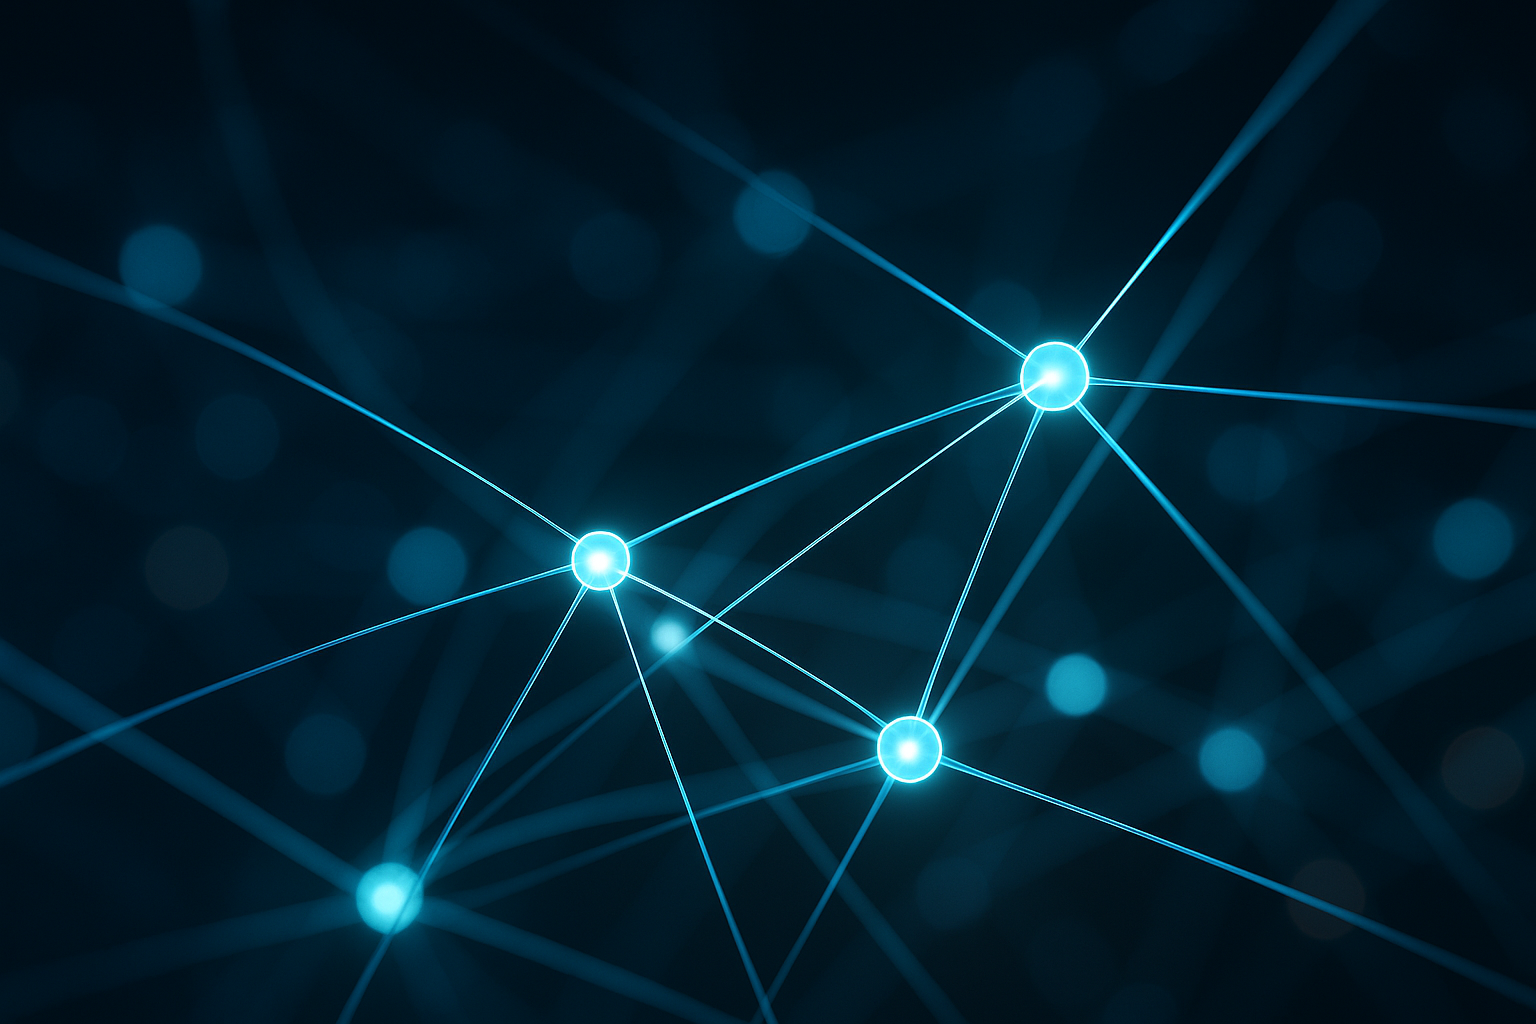

In [29]:
Image(base64.b64decode(img_resp.content_blocks[0]['base64']))

In [30]:
llm5 = ChatOpenAI(model="gpt-5.2")

In [31]:
def encode_image(image_path):
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode("utf-8")

In [32]:
img = encode_image("nrn.png")

In [33]:
resp5 = llm5.invoke(input=[
    HumanMessage(content=[
        {"type":"text","text":"Qu'est ce que tu vois dans cette image"},
        {"type":"image_url", "image_url": {"url": f"data:image/png;base64,{img}"}}
    ])])

In [34]:
print(display(Markdown(resp5.content)))

Je vois une illustration abstraite en tons bleus/violets : des sphères lumineuses reliées entre elles par de fines lignes, formant un réseau en 3D. Ça évoque un réseau de neurones (synapses) ou un réseau moléculaire/technologique.

None


In [35]:
import session_info
import pandas as pd
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
import numpy as np
from datasets import load_dataset
from dotenv.ipython import load_dotenv
import session_info
import matplotlib.pyplot  as plt

In [36]:
corpus = load_dataset("imdb")

In [37]:
train_df = corpus['train'].to_pandas()

In [38]:
train_df.head()

,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0


In [39]:
train_df['sentiment'] = np.where(train_df.label == 1, "positive", "negative")

In [40]:
train_df.head()

,text,label,sentiment
0,I rented I AM CURIOUS-YELLOW from my video sto...,0,negative
1,"""I Am Curious: Yellow"" is a risible and preten...",0,negative
2,If only to avoid making this type of film in t...,0,negative
3,This film was probably inspired by Godard's Ma...,0,negative
4,"Oh, brother...after hearing about this ridicul...",0,negative


In [74]:
standard_system_message = """
Classify the sentiment of movie reviews presented in the input as 'positive' or 'negative'
Movie reviews will be delimited by triple backticks in the input.
Answer only 'positive' or 'negative' 
Do not explain your answer.
"""

In [75]:
zero_shot_prompt = [{'role':'system', 'content': standard_system_message}]

In [53]:
user_message_template = """```{movie_review}```"""

In [45]:
prompt_examples,gold_examples = train_test_split(
    train_df, test_size=0.2, random_state=42
)

In [80]:
gold_examples = gold_examples[["text", "sentiment"]].sample(20, random_state=42).to_json(orient="records")

In [90]:
def create_examples(data, columns_to_select=["text","sentiment"],sample=4):
    positive_example=data[data.sentiment == "positive"].sample(sample)[columns_to_select]
    negative_example=data[data.sentiment == "negative"].sample(sample)[columns_to_select]
    examples = pd.concat([positive_example, negative_example])
    return examples.sample(2*sample,replace=False).to_json(orient="records")

In [ ]:
examples = create_examples(prompt_examples,sample=4)

In [52]:
json.loads(examples) 

[{'text': 'Batman and Superman. Iconic. The better part of a century old. Who doesn\'t know of these two? There must be countless of fans who would die to make a film about them. Sandy Collora went ahead and put together a trailer for such a film(which does not exist, and is not being created, much less by this team). Perhaps what this has most going for it is how polished it is. Throughout, the cinematography is solid. The editing is spot-on. The production values, even with the costumes looking more like their comic counterparts than the ones of the feature films featuring these character, are quite high. It looks quite "Hollywood", this trailer. The physical types fit for, as far as I can tell, every single character. The lines are reasonably written. The shots are well-thought up, nicely achieved and fairly effective. However, this does have problems, and in spite of looking good, it doesn\'t quite match the energy and skill of Grayson(which only had the problem of teeter-tottering

In [68]:
def create_few_shot_prompt(system_message, examples, user_message_template):
    few_shot_prompt = [{"role":"system", "content": system_message}]
    for example in json.loads(examples):
        few_shot_prompt.append({"role":"user", "content": user_message_template.format(movie_review=example["text"])})
        few_shot_prompt.append({"role":"assistant", "content": example["sentiment"]})
    return few_shot_prompt

In [76]:
few_shot_prompt = create_few_shot_prompt(
    system_message=standard_system_message,
    examples=examples,
    user_message_template=user_message_template
)

In [70]:
few_shot_prompt

[{'role': 'system',
  'content': "\nClassify the sentiment of movie reviews presented in the input as 'positive' or 'negative'\nMovie reviews will be delimited by triple backticks in the input.\nAnswer only 'positive' or 'negative' \nDo not explain your answer.\n"},
 {'role': 'user',
  'content': '```Batman and Superman. Iconic. The better part of a century old. Who doesn\'t know of these two? There must be countless of fans who would die to make a film about them. Sandy Collora went ahead and put together a trailer for such a film(which does not exist, and is not being created, much less by this team). Perhaps what this has most going for it is how polished it is. Throughout, the cinematography is solid. The editing is spot-on. The production values, even with the costumes looking more like their comic counterparts than the ones of the feature films featuring these character, are quite high. It looks quite "Hollywood", this trailer. The physical types fit for, as far as I can tell, ev

In [62]:
cot_system_message = """
Classify the sentiment of movie reviews presented in the input as 'positive' or 'negative'
Movie reviews will be delimited by triple backticks ``` in the input.
Answer only 'positive' or 'negative' 
Do not explain your answer.

Instructions:
1. Carefully read the text of the review and think through the options for sentiment provided
2. Consider the overall sentiment of the review and estimate the probability of the review being positive

To reiterate, your answer should strictly only contain the label: positive or negative
"""

In [71]:
cot_prompt = create_few_shot_prompt(
    system_message=cot_system_message,  
    examples=examples,
    user_message_template=user_message_template
)

In [85]:
def evaluate_model_on_gold_examples(prompt, gold_examples, user_message_template,model):
    true = []
    pred = []
    for example in json.loads(gold_examples):
        user_input = [{"role":"user", "content": user_message_template.format(movie_review=example["text"])}]
        response = model.invoke(
            prompt+user_input
        )
        if hasattr(response, "content"):
            response_content = response.content
            if "positive" in response_content.strip().lower():
                pred.append(response_content.strip().lower())
            elif "negative" in response_content.strip().lower():
                pred.append("negative")
            else:
                pred.append("unknown")
        true.append(example["sentiment"])
        micro_f1_score = f1_score(true, pred, average="micro")
    return micro_f1_score

In [65]:
gpt5 = ChatOpenAI(
    model="gpt-5.2", temperature=0
    )

In [86]:
evaluate_model_on_gold_examples(zero_shot_prompt, gold_examples, user_message_template, gpt5)

1.0

In [87]:
evaluate_model_on_gold_examples(few_shot_prompt, gold_examples, user_message_template, gpt5)

1.0

In [88]:
evaluate_model_on_gold_examples(cot_prompt, gold_examples, user_message_template, gpt5)

1.0

In [92]:
num_eval_runs = 10
few_shot_performance, cot_few_shot_performance = [], []
for _ in tqdm(range(num_eval_runs)):

    # For each run create a new sample of examples
    examples = create_examples(prompt_examples)

    # Assemble the few shot prompt with these examples
    few_shot_prompt = create_few_shot_prompt(standard_system_message, examples, user_message_template)
    cot_few_shot_prompt = create_few_shot_prompt(cot_system_message, examples, user_message_template)

    # Evaluate prompt accuracy on gold examples
    few_shot_micro_f1 = evaluate_model_on_gold_examples(few_shot_prompt, gold_examples, user_message_template, gpt5)
    cot_few_shot_micro_f1 = evaluate_model_on_gold_examples(cot_few_shot_prompt, gold_examples, user_message_template, gpt5)
    
    few_shot_performance.append(few_shot_micro_f1)
    cot_few_shot_performance.append(cot_few_shot_micro_f1)


100%|██████████| 10/10 [05:45<00:00, 34.57s/it]


In [94]:
few_shot_performance

[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]

In [95]:
cot_few_shot_performance

[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]